<a href="https://colab.research.google.com/github/isocan/ML-accelerated-ORR/blob/main/Ni_NiCl2_reference_electrode_MLIP_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MLIP Study II: Atomistic origin of stability in saturated Ni/NiCl₂ reference electrodes

## Proposed research question

**Can DFT-informed machine-learning molecular dynamics explain why saturated Ni/NiCl₂ reference electrodes become stable in eutectic LiCl–KCl, by connecting Ni(II) coordination, association, transport, and chemical potential to the concentration dependence of the reference potential?**

### Why this is a strong follow-up study

Recent experiments reported that NiCl₂-containing reference electrodes in eutectic LiCl–KCl at **773 K** remain stable and reach a saturation regime at about **15 mol% NiCl₂ or above**. Separate spectroscopy/AIMD work shows that Ni(II) in LiCl–KCl has a strongly structured chloride coordination environment, with tetrahedral Ni(II) coordination being an important motif.

At the same time:

- MLIPs have already reproduced bulk molten LiCl/KCl structure and transport.
- MLIP-accelerated free-energy calculations have been demonstrated for molten-salt chemical potentials.
- MLIPs have been used for Ni | LiCl–KCl interfaces and, separately, for long-timescale metal–electrolyte interfaces.
- A direct **MLIP study of the saturated Ni/NiCl₂ thermodynamic reference electrode** was not identified in the literature search used to design this notebook.

This makes the concentration-dependent Ni/NiCl₂ problem a natural bridge between **molten-salt MLIPs, electrochemical thermodynamics, spectroscopy, and reference-electrode durability**.

### Literature anchors

1. Mejia & Rappleye, *Nuclear Engineering and Technology* 58 (2026) 103875.  
   DOI: `10.1016/j.net.2025.103875`
2. Mejia & Rappleye, *Electrochimica Acta* 512 (2025) 145496.  
   DOI: `10.1016/j.electacta.2024.145496`
3. Correlative Ni(II) coordination study, *Chemical Science* (2025).  
   DOI: `10.1039/D5SC01059D`
4. Chemical potentials with ML-accelerated molten-salt simulations, *Chemical Science* (2025).  
   DOI: `10.1039/D4SC07253G`
5. Ni | eutectic LiCl–KCl interface with deep-learning MD, *Chemical Physics Letters* (2025).  
   DOI: `10.1016/j.cplett.2025.142476`
6. LiCl/KCl neural-network potential, *J. Phys. Chem. C* (2024).  
   DOI: `10.1021/acs.jpcc.3c07010`

---

## Scope of this notebook

This notebook is a **research-project starter**, not a claim that a universal MLIP already predicts the Ni/NiCl₂ electrochemical potential quantitatively.

It performs:

1. Colab-safe installation of `MoltenSaltCalc + MACE`.
2. Composition generation for eutectic LiCl–KCl + NiCl₂.
3. A **melt → NPT equilibration → gradual cooling → 773 K production** protocol.
4. Correct ASE stress-to-bar conversion.
5. Concentration-dependent analysis:
   - density,
   - Ni–Cl RDF,
   - Ni coordination-number distribution,
   - Ni–Ni association/proximity,
   - species diffusion,
   - Nernst–Einstein conductivity proxy.
6. Ideal Nernst concentration dependence for Ni/NiCl₂.
7. A scaffold for adding **MLIP free-energy/chemical-potential corrections**.
8. Automatic DFT-label export for active learning/fine-tuning.
9. Optional construction of a **Ni(111) | LiCl–KCl–NiCl₂ interface**.

The central electrochemical reaction is

\[
\mathrm{NiCl_2 + 2e^- \rightleftharpoons Ni + 2Cl^-}.
\]

A classical/short-range MLIP trajectory does **not** directly provide electrode voltage. The quantitative reference potential must ultimately be obtained through a thermodynamic free-energy relation.



## 1. Colab environment setup

The current `MoltenSaltCalc[mace]` dependency set pins **PyTorch 2.9.1**.  
The matching PyTorch stack is:

- `torch==2.9.1`
- `torchvision==0.24.1`
- `torchaudio==2.9.1`

This avoids the `torchvision::nms does not exist` binary mismatch encountered in some current Colab images.

**First run:** this cell may restart the kernel once.  
After reconnection, run the notebook from the top again.


In [1]:

# 1a. Colab-safe environment bootstrap

from __future__ import annotations

import importlib.metadata as im
import importlib.util
import os
from pathlib import Path
import signal
import subprocess
import sys

TORCH_VERSION = "2.9.1"
TORCHVISION_VERSION = "0.24.1"
TORCHAUDIO_VERSION = "2.9.1"
PYTORCH_INDEX = "https://download.pytorch.org/whl/cu128"

REPO_DIR = Path("MoltenSaltCalc")
REPO_URL = "https://github.com/leiapple/MoltenSaltCalc.git"
AUTO_RESTART = True


def dist_version(name):
    try:
        return im.version(name)
    except im.PackageNotFoundError:
        return None


def base_version(v):
    return None if v is None else v.split("+")[0]


versions = {
    "torch": dist_version("torch"),
    "torchvision": dist_version("torchvision"),
    "torchaudio": dist_version("torchaudio"),
    "moltensaltcalc": dist_version("moltensaltcalc"),
}

print("Current environment")
for k, v in versions.items():
    print(f"{k:16s}: {v}")

torch_ok = (
    base_version(versions["torch"]) == TORCH_VERSION
    and base_version(versions["torchvision"]) == TORCHVISION_VERSION
    and base_version(versions["torchaudio"]) == TORCHAUDIO_VERSION
)

changed = False

if not torch_ok:
    subprocess.run(
        [
            sys.executable, "-m", "pip", "uninstall", "-y",
            "torch", "torchvision", "torchaudio"
        ],
        check=False,
    )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--no-cache-dir",
            f"torch=={TORCH_VERSION}",
            f"torchvision=={TORCHVISION_VERSION}",
            f"torchaudio=={TORCHAUDIO_VERSION}",
            "--index-url", PYTORCH_INDEX,
        ],
        check=True,
    )
    changed = True

if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
        check=True,
    )

if importlib.util.find_spec("moltensaltcalc") is None:
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--no-cache-dir",
            f"{REPO_DIR}[mace]",
            "pandas", "matplotlib",
        ],
        check=True,
    )
    changed = True

# Keep current Colab's requests requirement clean.
if base_version(dist_version("requests")) != "2.32.4":
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "requests==2.32.4"],
        check=True,
    )
    changed = True

if changed:
    print("\nEnvironment changed; kernel restart required.")
    if AUTO_RESTART:
        print("Restarting kernel...")
        sys.stdout.flush()
        try:
            ip = get_ipython()
            if ip is not None and hasattr(ip, "kernel"):
                ip.kernel.do_shutdown(restart=True)
            else:
                raise RuntimeError
        except Exception:
            os.kill(os.getpid(), signal.SIGKILL)
    else:
        raise RuntimeError("Restart the kernel manually and rerun from the top.")
else:
    print("\nEnvironment already compatible.")


Current environment
torch           : 2.11.0+cu128
torchvision     : 0.26.0+cu128
torchaudio      : 2.11.0+cu128
moltensaltcalc  : None

Environment changed; kernel restart required.
Restarting kernel...


In [2]:

# 1b. Verify binary compatibility

import torch
import torchvision
import torchaudio
from torchvision.ops import nms

print("torch       :", torch.__version__)
print("torchvision :", torchvision.__version__)
print("torchaudio  :", torchaudio.__version__)
print("CUDA build  :", torch.version.cuda)
print("CUDA ready  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))

assert torch.__version__.split("+")[0] == "2.9.1"
assert torchvision.__version__.split("+")[0] == "0.24.1"

boxes = torch.tensor(
    [[0.0, 0.0, 10.0, 10.0], [1.0, 1.0, 9.0, 9.0]],
    dtype=torch.float32,
)
scores = torch.tensor([0.9, 0.8])
print("NMS test:", nms(boxes, scores, 0.5).tolist())


torch       : 2.9.1+cu128
torchvision : 0.24.1+cu128
torchaudio  : 2.9.1+cu128
CUDA build  : 12.8
CUDA ready  : True
GPU         : Tesla T4
NMS test: [0]


In [3]:

# 2. Imports

from dataclasses import dataclass, asdict
from pathlib import Path
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ase import Atoms, units
from ase.build import fcc111
from ase.constraints import FixAtoms, FixCom
from ase.data import atomic_masses, atomic_numbers
from ase.io import Trajectory, read, write
from ase.md.langevin import Langevin
from ase.md.nptberendsen import NPTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary

from moltensaltcalc import MoltenSaltSimulator, MoltenSaltAnalyzer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Using:", DEVICE)


Using: cuda



## 3. Study design

Experiments at 773 K report a saturated NiCl₂ reference-electrode regime at approximately **15 mol% or greater**. The concentration sweep below samples the approach to that regime.

For each nominal NiCl₂ mole fraction \(x_{\mathrm{NiCl_2}}\), the remaining carrier salt is distributed according to the eutectic-like LiCl/KCl ratio:

\[
x_{\mathrm{LiCl}}:x_{\mathrm{KCl}}
=
0.585:0.415.
\]

Charge-neutral atom counts follow

\[
N_{\mathrm{Cl}}
=
N_{\mathrm{Li}}
+
N_{\mathrm K}
+
2N_{\mathrm{Ni}}.
\]

### Recommended production grid

\[
x_{\mathrm{NiCl_2}}
=
0.005,\ 0.01,\ 0.025,\ 0.05,\ 0.10,\ 0.15.
\]

The default demo uses only 1, 5, and 15 mol% so the notebook remains practical on a Colab T4.


In [4]:

# 3a. Configuration

@dataclass
class StudyConfig:
    project_name: str = "Ni_NiCl2_LiClKCl_MLIP"

    target_temperature_K: float = 773.0
    melt_temperature_K: float = 1200.0
    pressure_bar: float = 1.01325

    # Number of salt formula units before expanding NiCl2 to 2 chloride ions.
    n_formula_units: int = 80

    # Fast demo vs research-quality production.
    demo: bool = True

    demo_concentrations: tuple = (0.01, 0.05, 0.15)
    production_concentrations: tuple = (0.005, 0.01, 0.025, 0.05, 0.10, 0.15)

    timestep_soft_fs: float = 0.25
    timestep_prod_fs: float = 1.0

    soft_steps_demo: int = 400
    npt_steps_per_stage_demo: int = 500
    nvt_steps_demo: int = 2000

    soft_steps_prod: int = 5000
    npt_steps_per_stage_prod: int = 20000
    nvt_steps_prod: int = 100000

    write_interval_demo: int = 10
    write_interval_prod: int = 20

    # Initial packing only; NPT must determine the final density.
    base_density_guess_g_cm3: float = 1.65

cfg = StudyConfig()

ROOT = Path(cfg.project_name)
for sub in [
    "trajectories",
    "analysis",
    "figures",
    "dft_labels",
    "interface",
    "metadata",
]:
    (ROOT / sub).mkdir(parents=True, exist_ok=True)

(ROOT / "metadata/config.json").write_text(
    json.dumps(asdict(cfg), indent=2)
)

CONCENTRATIONS = (
    cfg.demo_concentrations
    if cfg.demo
    else cfg.production_concentrations
)

cfg


StudyConfig(project_name='Ni_NiCl2_LiClKCl_MLIP', target_temperature_K=773.0, melt_temperature_K=1200.0, pressure_bar=1.01325, n_formula_units=80, demo=True, demo_concentrations=(0.01, 0.05, 0.15), production_concentrations=(0.005, 0.01, 0.025, 0.05, 0.1, 0.15), timestep_soft_fs=0.25, timestep_prod_fs=1.0, soft_steps_demo=400, npt_steps_per_stage_demo=500, nvt_steps_demo=2000, soft_steps_prod=5000, npt_steps_per_stage_prod=20000, nvt_steps_prod=100000, write_interval_demo=10, write_interval_prod=20, base_density_guess_g_cm3=1.65)

In [5]:

# 3b. Convert NiCl2 mole fraction into atom counts

def composition_from_nicl2_fraction(
    x_nicl2,
    n_formula_units=80,
    x_licl_in_host=0.585,
):
    if not (0 < x_nicl2 < 1):
        raise ValueError("x_nicl2 must lie between 0 and 1.")

    n_ni = max(1, int(round(n_formula_units * x_nicl2)))
    n_host = n_formula_units - n_ni

    n_li = int(round(n_host * x_licl_in_host))
    n_k = n_host - n_li

    # Li+, K+, Ni2+, Cl-
    n_cl = n_li + n_k + 2 * n_ni

    actual_x = n_ni / (n_host + n_ni)

    return {
        "x_NiCl2_target": x_nicl2,
        "x_NiCl2_actual": actual_x,
        "Li": n_li,
        "K": n_k,
        "Ni": n_ni,
        "Cl": n_cl,
        "n_atoms": n_li + n_k + n_ni + n_cl,
    }


composition_table = pd.DataFrame(
    [
        composition_from_nicl2_fraction(
            x,
            cfg.n_formula_units,
        )
        for x in CONCENTRATIONS
    ]
)

display(composition_table)


,x_NiCl2_target,x_NiCl2_actual,Li,K,Ni,Cl,n_atoms
0,0.01,0.0125,46,33,1,81,161
1,0.05,0.0500,44,32,4,84,164
2,0.15,0.1500,40,28,12,92,172



## 4. Baseline MLIP

We use the same MACE-OMAT foundation model as a **zero-shot baseline**, with a D3(BJ)-type dispersion contribution through `MoltenSaltCalc`.

The model is *not* assumed to be quantitatively correct for Ni\(^{2+}\), NiCl₂ activities, or a Ni metal/electrolyte redox process. This first pass is used to:

- generate plausible liquid configurations,
- identify model failures,
- estimate which composition regions require DFT labels,
- and prepare an active-learning dataset.

A paper-quality result requires DFT benchmarking/fine-tuning.


In [6]:

# 4a. Initialize MACE through MoltenSaltCalc

MACE_OMAT_URL = (
    "https://github.com/ACEsuit/mace-foundations/releases/download/"
    "mace_omat_0/mace-omat-0-medium.model?raw=true"
)

sim = MoltenSaltSimulator(
    model_name="mace",
    model_parameters={
        "model_path": MACE_OMAT_URL,
        # The downloaded OMat model currently exposes a "default" head.
        "model_task": "default",
    },
    device=DEVICE,
    dispersion="DFTD3",
    dispersion_functional="pbe",
)

assert sim.calc is not None
print(type(sim.calc))


/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


Downloading: 100.0% (75.8 MB / 75.8 MB)
Cached MACE model to /root/.cache/mace/maceomat0mediummodelrawtrue
Using Materials Project MACE for MACECalculator with /root/.cache/mace/maceomat0mediummodelrawtrue
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


<class 'ase.calculators.mixing.SumCalculator'>



## 5. Build the concentration sweep

A rocksalt-like packing is used **only as the initial coordinate generator**.  
The key improvement relative to a direct 773 K start is that each system is first subjected to a strongly thermostatted high-temperature "soft landing", followed by NPT equilibration and gradual cooling:

\[
1200 \rightarrow 1000 \rightarrow 850 \rightarrow 773\ \mathrm{K}.
\]

This reduces the risk that large forces stored in an artificial crystalline/mixed starting arrangement are converted into an uncontrolled temperature spike.


In [7]:

# 5a. Build one composition

def initial_density_guess(x_nicl2):
    # Packing guess only. This weak composition trend is deliberately modest.
    return cfg.base_density_guess_g_cm3 + 0.8 * x_nicl2


def build_nicl2_melt(comp, seed=42):
    np.random.seed(seed)

    atoms = sim.build_system(
        salt_anion=["Cl"],
        salt_cation=["Li", "K", "Ni"],
        n_anions=[int(comp["Cl"])],
        n_cations=[
            int(comp["Li"]),
            int(comp["K"]),
            int(comp["Ni"]),
        ],
        density_guess=initial_density_guess(comp["x_NiCl2_actual"]),
        lattice="rocksalt",
        cubic_cell=True,
        random_removal=True,
    )

    atoms.info["x_NiCl2"] = float(comp["x_NiCl2_actual"])
    atoms.info["temperature_target_K"] = cfg.target_temperature_K

    return atoms


initial_systems = {}
sanity_rows = []

for _, row in composition_table.iterrows():
    x = float(row["x_NiCl2_actual"])
    atoms = build_nicl2_melt(row, seed=SEED + int(round(x * 10000)))

    E = atoms.get_potential_energy()
    F = atoms.get_forces()
    fmag = np.linalg.norm(F, axis=1)

    D = atoms.get_all_distances(mic=True)
    D += np.eye(len(atoms)) * 1e9

    initial_systems[x] = atoms
    sanity_rows.append({
        "x_NiCl2": x,
        "n_atoms": len(atoms),
        "E_eV_atom": E / len(atoms),
        "Fmax_eV_A": fmag.max(),
        "Fmean_eV_A": fmag.mean(),
        "min_distance_A": D.min(),
        "finite": np.isfinite(E) and np.isfinite(F).all(),
    })

sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df)

assert sanity_df["finite"].all()


/usr/local/lib/python3.12/dist-packages/torch_dftd/torch_dftd3_calculator.py:98: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  cell: Optional[Tensor] = torch.tensor(


,x_NiCl2,n_atoms,E_eV_atom,Fmax_eV_A,Fmean_eV_A,min_distance_A,finite
0,0.0125,161,-2.679864,3.758568,1.615370,2.759958,True
1,0.0500,164,-2.699922,3.699655,1.455314,2.788995,True
2,0.1500,172,-2.672120,2.904115,1.435934,2.851470,True



## 6. Correctly monitored MD

### Important pressure detail

ASE stress is returned in internal pressure units equivalent to eV Å\(^{-3}\).  
The helper below converts the instantaneous hydrostatic pressure to **bar** using `units.bar`.

This avoids interpreting raw ASE stress values as bar.

The production protocol is:

1. strong-friction NVT at 1200 K,
2. NPT at 1200 K,
3. NPT cooling at 1000, 850, and 773 K,
4. fixed-volume NVT production at 773 K.

For a publication, extend the equilibration until density and pressure plateau and run multiple independent replicas.


In [8]:

# 6a. MD helpers

def instantaneous_pressure_bar(atoms):
    stress = atoms.get_stress(voigt=False)
    hydrostatic_stress = np.trace(stress) / 3.0
    pressure = -hydrostatic_stress
    return float(pressure / units.bar)


def run_langevin(
    atoms,
    T,
    steps,
    timestep_fs,
    traj_file,
    logfile,
    write_interval=10,
    tdamp_fs=20.0,
):
    atoms = atoms.copy()
    atoms.calc = sim.calc
    atoms.set_constraint(FixCom())

    MaxwellBoltzmannDistribution(
        atoms,
        temperature_K=T,
        force_temp=True,
    )
    Stationary(atoms)

    dyn = Langevin(
        atoms,
        timestep=timestep_fs * units.fs,
        temperature_K=T,
        friction=1.0 / (tdamp_fs * units.fs),
        logfile=str(logfile),
        loginterval=write_interval,
        fixcm=False,
    )

    traj = Trajectory(
        traj_file,
        "w",
        atoms,
        properties=["energy", "forces", "stress"],
    )

    def write_frame():
        atoms.info["time_fs"] = dyn.get_time() / units.fs
        atoms.info["pressure_bar"] = instantaneous_pressure_bar(atoms)
        traj.write(atoms)

    write_frame()
    dyn.attach(write_frame, interval=write_interval)
    dyn.run(steps)
    traj.close()

    return atoms


def run_npt_berendsen(
    atoms,
    T,
    steps,
    timestep_fs,
    pressure_bar,
    traj_file,
    logfile,
    write_interval=10,
    taut_fs=100.0,
    taup_fs=1000.0,
    compressibility_per_bar=5e-6,
):
    atoms = atoms.copy()
    atoms.calc = sim.calc
    atoms.set_constraint(FixCom())

    if not np.isfinite(atoms.get_temperature()) or atoms.get_temperature() < 1:
        MaxwellBoltzmannDistribution(
            atoms,
            temperature_K=T,
            force_temp=True,
        )

    dyn = NPTBerendsen(
        atoms,
        timestep=timestep_fs * units.fs,
        temperature_K=T,
        taut=taut_fs * units.fs,
        pressure_au=pressure_bar * units.bar,
        taup=taup_fs * units.fs,
        compressibility_au=compressibility_per_bar / units.bar,
        logfile=str(logfile),
        loginterval=write_interval,
    )

    traj = Trajectory(
        traj_file,
        "w",
        atoms,
        properties=["energy", "forces", "stress"],
    )

    def write_frame():
        atoms.info["time_fs"] = dyn.get_time() / units.fs
        atoms.info["pressure_bar"] = instantaneous_pressure_bar(atoms)
        traj.write(atoms)

    write_frame()
    dyn.attach(write_frame, interval=write_interval)
    dyn.run(steps)
    traj.close()

    return atoms


In [9]:

# 6b. Melt -> cool -> 773 K production for one composition

COOLING_SCHEDULE_K = [
    cfg.melt_temperature_K,
    1000.0,
    850.0,
    cfg.target_temperature_K,
]

soft_steps = (
    cfg.soft_steps_demo
    if cfg.demo
    else cfg.soft_steps_prod
)

npt_steps = (
    cfg.npt_steps_per_stage_demo
    if cfg.demo
    else cfg.npt_steps_per_stage_prod
)

nvt_steps = (
    cfg.nvt_steps_demo
    if cfg.demo
    else cfg.nvt_steps_prod
)

write_interval = (
    cfg.write_interval_demo
    if cfg.demo
    else cfg.write_interval_prod
)


def run_composition_protocol(x, atoms):
    tag = f"NiCl2_{100*x:.2f}molpct".replace(".", "p")
    outdir = ROOT / "trajectories" / tag
    outdir.mkdir(parents=True, exist_ok=True)

    # 1. Soft high-T NVT
    soft_traj = outdir / "00_soft_1200K.traj"
    atoms = run_langevin(
        atoms,
        T=cfg.melt_temperature_K,
        steps=soft_steps,
        timestep_fs=cfg.timestep_soft_fs,
        traj_file=soft_traj,
        logfile=outdir / "00_soft.log",
        write_interval=write_interval,
        tdamp_fs=10.0,
    )

    # 2. NPT at progressively lower T
    stage_files = []
    for i, T in enumerate(COOLING_SCHEDULE_K, start=1):
        stage_traj = outdir / f"{i:02d}_npt_{int(T)}K.traj"
        atoms = run_npt_berendsen(
            atoms,
            T=T,
            steps=npt_steps,
            timestep_fs=cfg.timestep_prod_fs,
            pressure_bar=cfg.pressure_bar,
            traj_file=stage_traj,
            logfile=outdir / f"{i:02d}_npt_{int(T)}K.log",
            write_interval=write_interval,
        )
        stage_files.append(stage_traj)

    # 3. NVT production at 773 K
    prod_traj = outdir / "05_nvt_773K.traj"
    atoms = run_langevin(
        atoms,
        T=cfg.target_temperature_K,
        steps=nvt_steps,
        timestep_fs=cfg.timestep_prod_fs,
        traj_file=prod_traj,
        logfile=outdir / "05_nvt_773K.log",
        write_interval=write_interval,
        tdamp_fs=100.0,
    )

    return {
        "tag": tag,
        "dir": outdir,
        "soft": soft_traj,
        "npt_stages": stage_files,
        "production": prod_traj,
        "final_atoms": atoms,
    }



### Computational-cost control

The following cell runs all concentrations selected by `CONCENTRATIONS`.

In **demo mode** it is intentionally short and should be interpreted only as a pipeline test.

For research-quality results, set:

```python
cfg.demo = False
```

and use multiple independent random seeds. For transport coefficients, aim for at least tens to hundreds of picoseconds with the final fine-tuned model.


In [10]:

# 6c. Run selected concentrations

RUN_MD = True

runs = {}

if RUN_MD:
    for x in sorted(initial_systems):
        print("\n" + "=" * 72)
        print(f"Running x(NiCl2) = {x:.4f}")
        print("=" * 72)

        runs[x] = run_composition_protocol(
            x,
            initial_systems[x],
        )
else:
    print("MD skipped.")



Running x(NiCl2) = 0.0125


/tmp/ipykernel_2407/3592206796.py:24: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(



Running x(NiCl2) = 0.0500

Running x(NiCl2) = 0.1500



## 7. Equilibration diagnostics

Before interpreting Ni speciation, verify:

- temperature settles close to 773 K,
- NPT density reaches a plateau,
- the correctly converted pressure fluctuates around the target rather than showing a systematic drift,
- there are no extremely short contacts,
- energy remains stationary during production.

The demo is too short to establish rigorous equilibrium.


In [11]:

# 7a. Summarize final NPT and production behavior

def density_g_cm3(atoms):
    mass_g = atoms.get_masses().sum() * 1.66053906660e-24
    volume_cm3 = atoms.get_volume() * 1e-24
    return mass_g / volume_cm3


equil_rows = []

if RUN_MD:
    for x, run in runs.items():
        npt_frames = list(Trajectory(run["npt_stages"][-1]))
        prod_frames = list(Trajectory(run["production"]))

        npt_tail = npt_frames[max(0, int(0.7 * len(npt_frames))):]
        prod_tail = prod_frames[max(0, int(0.5 * len(prod_frames))):]

        equil_rows.append({
            "x_NiCl2": x,
            "rho_NPT_tail_g_cm3": np.mean(
                [density_g_cm3(a) for a in npt_tail]
            ),
            "T_NPT_tail_K": np.mean(
                [a.get_temperature() for a in npt_tail]
            ),
            "P_NPT_tail_bar": np.mean(
                [
                    a.info.get(
                        "pressure_bar",
                        instantaneous_pressure_bar(a),
                    )
                    for a in npt_tail
                ]
            ),
            "T_NVT_tail_K": np.mean(
                [a.get_temperature() for a in prod_tail]
            ),
            "E_NVT_tail_eV_atom": np.mean(
                [a.get_potential_energy() / len(a) for a in prod_tail]
            ),
        })

equil_df = pd.DataFrame(equil_rows)
display(equil_df)


,x_NiCl2,rho_NPT_tail_g_cm3,T_NPT_tail_K,P_NPT_tail_bar,T_NVT_tail_K,E_NVT_tail_eV_atom
0,0.0125,1.601824,800.610661,-5906.992111,805.297746,-3.567484
1,0.0500,1.641372,794.065912,-4195.028969,779.036092,-3.569670
2,0.1500,1.740721,810.408554,-8317.431580,785.313402,-3.576440


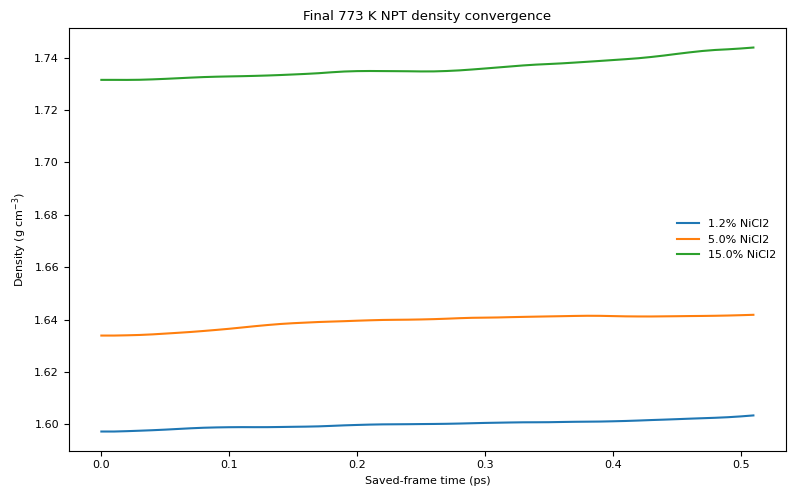

In [12]:

# 7b. Plot temperature and density for the final NPT stage

if RUN_MD:
    fig, ax = plt.subplots(figsize=(8, 5))

    for x, run in runs.items():
        frames = list(Trajectory(run["npt_stages"][-1]))
        times_ps = np.arange(len(frames)) * write_interval * cfg.timestep_prod_fs / 1000
        dens = [density_g_cm3(a) for a in frames]
        ax.plot(times_ps, dens, label=f"{100*x:.1f}% NiCl2")

    ax.set_xlabel("Saved-frame time (ps)")
    ax.set_ylabel(r"Density (g cm$^{-3}$)")
    ax.set_title("Final 773 K NPT density convergence")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(ROOT / "figures/density_convergence.png", dpi=200)
    plt.show()



## 8. Ni(II) local structure: the central mechanistic observable

Spectroscopy and AIMD studies identify **tetrahedral Ni(II) chloride coordination** as an important structural motif in eutectic LiCl–KCl.

The main concentration-dependent question is therefore:

> Does the fraction and lifetime of tetrahedral Ni–Cl environments remain unchanged, or does it reorganize as NiCl₂ approaches the experimental saturation regime?

We compute:

- Ni–Cl RDF,
- an automatically estimated first-shell cutoff,
- Ni coordination-number distribution,
- fraction of Ni atoms with coordination number 4.


In [13]:

# 8a. RDF helper

def rdf_from_traj(traj_file, T=773.0, pairs=None, max_frames=300):
    analyzer = MoltenSaltAnalyzer(
        traj_files_nvt=[traj_file],
        temperatures_nvt=[T],
    )
    return analyzer.compute_rdf(
        T=T,
        max_num_frames=min(
            max_frames,
            len(Trajectory(traj_file)),
        ),
        rmax=7.0,
        nbins=160,
        pairs=pairs,
        n_workers=1,
    )


rdf_by_x = {}

if RUN_MD:
    for x, run in runs.items():
        rdf_by_x[x] = rdf_from_traj(
            run["production"],
            pairs=[
                ("Ni", "Cl"),
                ("Ni", "Ni"),
                ("Li", "Cl"),
                ("K", "Cl"),
            ],
        )


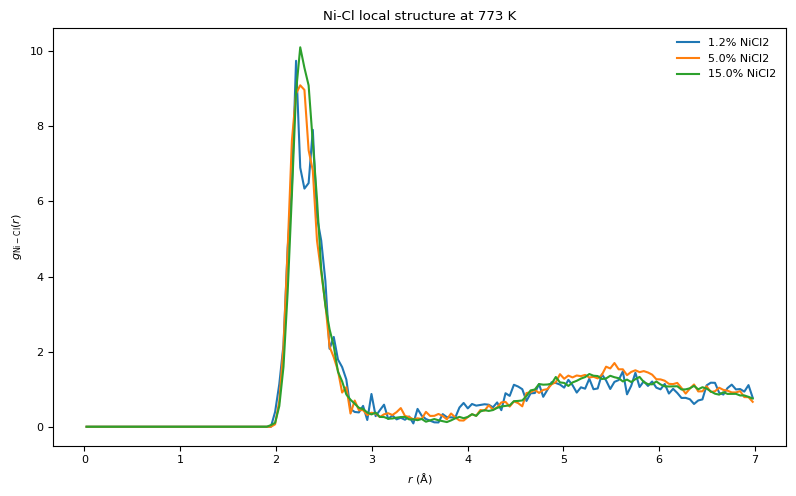

In [14]:

# 8b. Plot Ni-Cl RDF across concentration

if RUN_MD:
    fig, ax = plt.subplots(figsize=(8, 5))

    for x in sorted(rdf_by_x):
        r, g = rdf_by_x[x][("Ni", "Cl")]
        ax.plot(r, g, label=f"{100*x:.1f}% NiCl2")

    ax.set_xlabel(r"$r$ (Å)")
    ax.set_ylabel(r"$g_{\mathrm{Ni-Cl}}(r)$")
    ax.set_title("Ni-Cl local structure at 773 K")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(ROOT / "figures/NiCl_RDF_concentration.png", dpi=200)
    plt.show()


In [15]:

# 8c. Estimate the first Ni-Cl RDF minimum after the first peak.

def first_shell_cutoff(r, g, peak_window=(1.8, 3.2), search_to=4.2):
    r = np.asarray(r)
    g = np.asarray(g)

    peak_mask = (r >= peak_window[0]) & (r <= peak_window[1])
    if not peak_mask.any():
        return 3.2

    peak_idx_candidates = np.where(peak_mask)[0]
    peak_idx = peak_idx_candidates[np.argmax(g[peak_mask])]

    end_candidates = np.where(r <= search_to)[0]
    end_idx = end_candidates[-1]

    if end_idx <= peak_idx + 2:
        return 3.2

    segment = g[peak_idx + 1:end_idx + 1]
    min_idx = peak_idx + 1 + np.argmin(segment)

    return float(r[min_idx])


cutoffs = {}

if RUN_MD:
    for x in sorted(rdf_by_x):
        r, g = rdf_by_x[x][("Ni", "Cl")]
        cutoffs[x] = first_shell_cutoff(r, g)

pd.DataFrame(
    [{"x_NiCl2": x, "NiCl_cutoff_A": c} for x, c in cutoffs.items()]
)


,x_NiCl2,NiCl_cutoff_A
0,0.0125,3.434375
1,0.0500,3.959375
2,0.1500,3.784375


In [16]:

# 8d. Ni coordination-number distributions

def coordination_numbers_for_frames(frames, center="Ni", neighbor="Cl", cutoff=3.2):
    all_cn = []

    for atoms in frames:
        symbols = np.array(atoms.get_chemical_symbols())
        centers = np.where(symbols == center)[0]
        neighbors = np.where(symbols == neighbor)[0]

        D = atoms.get_all_distances(mic=True)

        for i in centers:
            cn = np.count_nonzero(D[i, neighbors] <= cutoff)
            all_cn.append(int(cn))

    return np.asarray(all_cn, dtype=int)


coordination_rows = []

if RUN_MD:
    for x, run in runs.items():
        frames = list(Trajectory(run["production"]))
        frames = frames[len(frames)//2:]

        cn = coordination_numbers_for_frames(
            frames,
            center="Ni",
            neighbor="Cl",
            cutoff=cutoffs[x],
        )

        for value in np.unique(cn):
            coordination_rows.append({
                "x_NiCl2": x,
                "coordination_number": int(value),
                "fraction": float(np.mean(cn == value)),
            })

coordination_df = pd.DataFrame(coordination_rows)
display(coordination_df)


,x_NiCl2,coordination_number,fraction
0,0.0125,4,0.415842
1,0.0125,5,0.584158
2,0.0500,4,0.289604
3,0.0500,5,0.415842
4,0.0500,6,0.294554
5,0.1500,4,0.353135
6,0.1500,5,0.387789
7,0.1500,6,0.259076


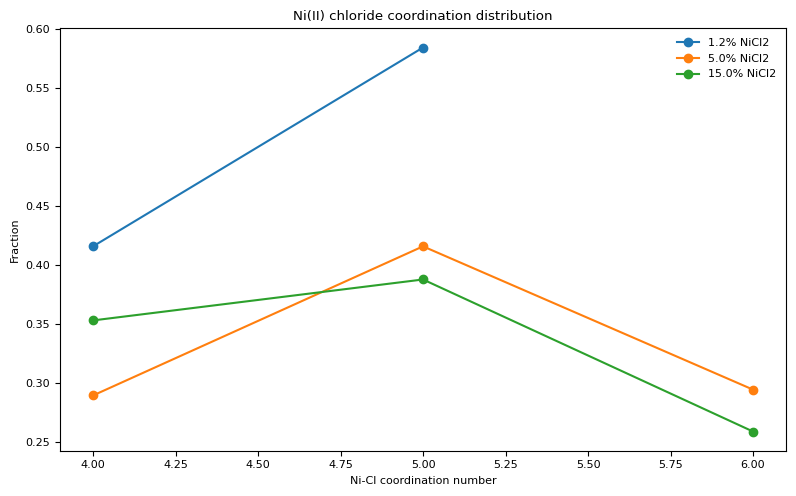

In [17]:

# 8e. Plot coordination-number distributions

if RUN_MD and len(coordination_df):
    fig, ax = plt.subplots(figsize=(8, 5))

    for x in sorted(coordination_df["x_NiCl2"].unique()):
        sub = coordination_df[coordination_df["x_NiCl2"] == x]
        ax.plot(
            sub["coordination_number"],
            sub["fraction"],
            marker="o",
            label=f"{100*x:.1f}% NiCl2",
        )

    ax.set_xlabel("Ni-Cl coordination number")
    ax.set_ylabel("Fraction")
    ax.set_title("Ni(II) chloride coordination distribution")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(ROOT / "figures/Ni_coordination_distribution.png", dpi=200)
    plt.show()



## 9. Ni–Ni association

A saturated reference solution may differ from a dilute solution not only through single-ion coordination but also through **Ni-containing short-range association**.

The metric below is deliberately described as a **Ni–Ni proximity probability**, not a chemical complex assignment. A full speciation analysis would require DFT-based electronic/structural validation.


In [18]:

# 9a. Ni-Ni nearest-neighbor/proximity statistics

def ni_ni_proximity(frames, cutoff_A=5.0):
    nearest = []
    close_fraction_by_frame = []

    for atoms in frames:
        symbols = np.array(atoms.get_chemical_symbols())
        ni = np.where(symbols == "Ni")[0]

        if len(ni) < 2:
            continue

        D = atoms.get_all_distances(mic=True)
        Dni = D[np.ix_(ni, ni)].copy()
        Dni += np.eye(len(ni)) * 1e9

        nearest.extend(Dni.min(axis=1).tolist())
        close_fraction_by_frame.append(
            np.mean(Dni.min(axis=1) <= cutoff_A)
        )

    return {
        "nearest_NiNi_A": np.asarray(nearest),
        "fraction_with_neighbor_within_cutoff": (
            np.mean(close_fraction_by_frame)
            if close_fraction_by_frame
            else np.nan
        ),
    }


association_rows = []

if RUN_MD:
    for x, run in runs.items():
        frames = list(Trajectory(run["production"]))
        frames = frames[len(frames)//2:]

        result = ni_ni_proximity(frames, cutoff_A=5.0)

        association_rows.append({
            "x_NiCl2": x,
            "mean_nearest_NiNi_A": (
                np.mean(result["nearest_NiNi_A"])
                if len(result["nearest_NiNi_A"])
                else np.nan
            ),
            "Ni_neighbor_fraction_r_lt_5A": result[
                "fraction_with_neighbor_within_cutoff"
            ],
        })

association_df = pd.DataFrame(association_rows)
display(association_df)


,x_NiCl2,mean_nearest_NiNi_A,Ni_neighbor_fraction_r_lt_5A
0,0.0125,NaN,NaN
1,0.0500,6.971242,0.000000
2,0.1500,4.270925,0.676568



## 10. Transport: PBC-unwrapped multi-time-origin MSD

Transport is secondary to the chemical-potential question, but it provides an important consistency test.

Because Ni is dilute at low concentration, its diffusion coefficient can have large uncertainty. Production studies should therefore use:

- longer trajectories,
- multiple independent replicas,
- and/or larger cells containing several Ni ions even in the dilute regime.

The code below unwraps a fixed-volume NVT trajectory before computing MSD.


In [19]:

# 10a. PBC-safe unwrapping and diffusion

def unwrap_fixed_cell(frames):
    frames = list(frames)
    cell = np.asarray(frames[0].cell)

    for f in frames[1:]:
        if not np.allclose(f.cell, cell, rtol=1e-8, atol=1e-8):
            raise ValueError("NVT trajectory must have a fixed cell.")

    frac = np.array(
        [f.get_scaled_positions(wrap=False) for f in frames],
        dtype=float,
    )

    dfrac = np.diff(frac, axis=0)
    dfrac -= np.rint(dfrac)

    unwrapped = np.empty_like(frac)
    unwrapped[0] = frac[0]
    unwrapped[1:] = frac[0] + np.cumsum(dfrac, axis=0)

    return unwrapped @ cell


def multi_origin_diffusion(
    frames,
    times_fs,
    fit_fraction=(0.35, 0.85),
    max_lags=160,
):
    frames = list(frames)
    pos = unwrap_fixed_cell(frames)

    symbols = np.array(frames[0].get_chemical_symbols())
    masses = frames[0].get_masses()

    # Remove residual COM translation.
    com = np.sum(
        pos * masses[None, :, None],
        axis=1,
    ) / masses.sum()

    pos = pos - com[:, None, :]

    n = len(frames)
    max_lag = max(2, n // 2)
    lags = np.unique(
        np.linspace(
            1,
            max_lag,
            min(max_lags, max_lag),
            dtype=int,
        )
    )

    results = {}

    for sp in np.unique(symbols):
        mask = symbols == sp
        lag_t = []
        msd = []

        for lag in lags:
            dr = pos[lag:, mask] - pos[:-lag, mask]
            msd.append(
                np.mean(np.sum(dr**2, axis=-1))
            )
            lag_t.append(
                np.mean(
                    np.asarray(times_fs[lag:])
                    - np.asarray(times_fs[:-lag])
                )
            )

        lag_t = np.asarray(lag_t)
        msd = np.asarray(msd)

        lo, hi = fit_fraction
        fit = (
            (lag_t >= lo * lag_t.max())
            & (lag_t <= hi * lag_t.max())
        )

        slope, intercept = np.polyfit(
            lag_t[fit],
            msd[fit],
            1,
        )

        D_A2_fs = slope / 6.0

        results[sp] = {
            "time_fs": lag_t,
            "msd_A2": msd,
            "D_A2_fs": D_A2_fs,
            "D_m2_s": D_A2_fs * 1e-5,
            "intercept": intercept,
        }

    return results


In [20]:

# 10b. Diffusion summary

diffusion_by_x = {}
diff_rows = []

if RUN_MD:
    for x, run in runs.items():
        frames = list(Trajectory(run["production"]))
        times = np.array([
            a.info.get(
                "time_fs",
                i * write_interval * cfg.timestep_prod_fs,
            )
            for i, a in enumerate(frames)
        ])

        result = multi_origin_diffusion(frames, times)
        diffusion_by_x[x] = result

        for sp, d in result.items():
            diff_rows.append({
                "x_NiCl2": x,
                "species": sp,
                "D_m2_s": d["D_m2_s"],
            })

diffusion_df = pd.DataFrame(diff_rows)
display(diffusion_df)


,x_NiCl2,species,D_m2_s
0,0.0125,Cl,1.981621e-09
1,0.0125,K,2.350564e-09
2,0.0125,Li,2.820004e-09
3,0.0125,Ni,1.579261e-09
4,0.0500,Cl,1.394466e-09
5,0.0500,K,2.055437e-09
6,0.0500,Li,2.654544e-09
7,0.0500,Ni,2.262458e-09
8,0.1500,Cl,9.623578e-10
9,0.1500,K,1.664163e-09


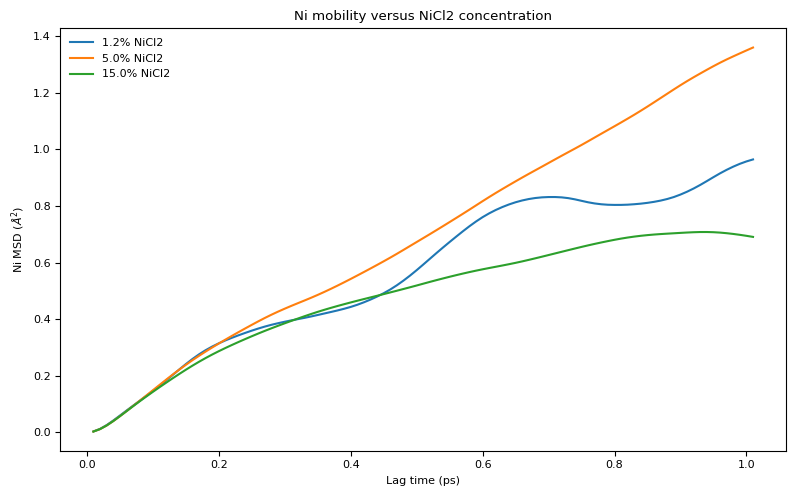

In [21]:

# 10c. Plot Ni MSD

if RUN_MD:
    fig, ax = plt.subplots(figsize=(8, 5))

    for x in sorted(diffusion_by_x):
        if "Ni" not in diffusion_by_x[x]:
            continue
        d = diffusion_by_x[x]["Ni"]
        ax.plot(
            d["time_fs"] / 1000,
            d["msd_A2"],
            label=f"{100*x:.1f}% NiCl2",
        )

    ax.set_xlabel("Lag time (ps)")
    ax.set_ylabel(r"Ni MSD ($\AA^2$)")
    ax.set_title("Ni mobility versus NiCl2 concentration")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(ROOT / "figures/Ni_MSD_concentration.png", dpi=200)
    plt.show()



## 11. Electrochemical connection: concentration dependence of Ni/NiCl₂

For

\[
\mathrm{NiCl_2 + 2e^- \rightleftharpoons Ni + 2Cl^-},
\]

a useful experimental form is

\[
E
=
E^\circ
+
\frac{RT}{2F}\ln \gamma_{\mathrm{NiCl_2}}
+
\frac{RT}{2F}\ln X_{\mathrm{NiCl_2}},
\]

under the chosen standard-state convention.

Published work on Ni corrosion/reference chemistry in eutectic LiCl–KCl at 773 K reported a hypothetical supercooled-liquid NiCl₂ standard reduction potential of approximately **−0.8109 V vs Cl₂/Cl⁻** for that convention.

The first plot below is deliberately the **ideal \(\gamma=1\)** baseline.  
It is not our final prediction.

The research objective is to compute

\[
\Delta\mu_{\mathrm{ex}}(x)
\]

with DFT-trained MLIP free-energy simulations, then obtain

\[
\ln\gamma(x)
=
\frac{\Delta\mu_{\mathrm{ex}}(x)}{RT}
\]

relative to a clearly defined reference state.


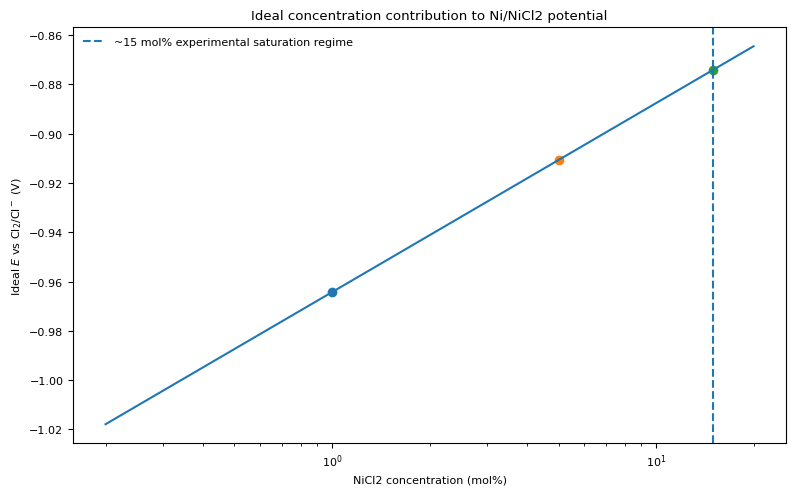

In [22]:

# 11a. Ideal Nernst concentration curve

R = 8.31446261815324
F = 96485.33212
T = cfg.target_temperature_K
E0_vs_Cl2_Cl = -0.8109  # V, literature standard-state convention at 773 K


def ideal_ni_reference_potential(x_nicl2, E0=E0_vs_Cl2_Cl, T=T):
    return E0 + R * T / (2 * F) * np.log(x_nicl2)


x_grid = np.logspace(
    np.log10(0.002),
    np.log10(0.20),
    200,
)

E_ideal = ideal_ni_reference_potential(x_grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(100*x_grid, E_ideal)

for x in CONCENTRATIONS:
    ax.scatter(
        [100*x],
        [ideal_ni_reference_potential(x)],
    )

ax.axvline(
    15.0,
    linestyle="--",
    label="~15 mol% experimental saturation regime",
)

ax.set_xscale("log")
ax.set_xlabel("NiCl2 concentration (mol%)")
ax.set_ylabel(r"Ideal $E$ vs Cl$_2$/Cl$^-$ (V)")
ax.set_title("Ideal concentration contribution to Ni/NiCl2 potential")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ROOT / "figures/ideal_Nernst_curve.png", dpi=200)
plt.show()


In [23]:

# 11b. Insert MLIP/free-energy corrections when available

def corrected_potential_from_delta_mu_ex(
    x_nicl2,
    delta_mu_ex_J_mol,
    E0=E0_vs_Cl2_Cl,
    T=T,
):
    """
    E = E0 + RT/(2F) ln(x) + Δμ_ex/(2F)

    Δμ_ex must correspond to the same NiCl2 chemical-potential convention
    as the chosen standard state.
    """
    return (
        E0
        + R*T/(2*F) * np.log(x_nicl2)
        + delta_mu_ex_J_mol/(2*F)
    )


# Example only:
# x = 0.05
# delta_mu_ex = ...  # J/mol from thermodynamic integration
# E = corrected_potential_from_delta_mu_ex(x, delta_mu_ex)



## 12. What the free-energy calculation should be

The central publishable quantity is not the RDF itself. It is the **NiCl₂ chemical potential/activity as a function of composition**.

A rigorous second-stage workflow should use an alchemical free-energy method analogous in spirit to recent MLIP chemical-potential calculations for molten LiCl:

### State A
Physical NiCl₂ dissolved in eutectic LiCl–KCl.

### State B
A reference/decoupled state defined so that the free-energy transformation is tractable.

### Thermodynamic integration

\[
\Delta G
=
\int_0^1
\left\langle
\frac{\partial U(\lambda)}
{\partial \lambda}
\right\rangle_\lambda
d\lambda.
\]

For ionic transformations, charge neutrality and the electrostatic/reference convention must be handled rigorously. Do **not** treat a single-ion absolute chemical potential from a neutral short-range MLIP as automatically well defined.

A practical project sequence is:

1. validate/fine-tune the MLIP on neutral Li/K/Ni/Cl configurations,
2. calculate the **neutral NiCl₂ formula-unit chemical potential**,
3. obtain concentration-dependent activity,
4. map activity into the Ni/NiCl₂ potential,
5. compare against experimental OCP/concentration data.



## 13. DFT labels for active learning

The foundation-model run should now be used to choose **DFT configurations**, not as the final source of thermodynamics.

For each concentration, export configurations from:

- the high-temperature melt,
- the cooling stages,
- the final 773 K liquid,
- unusual Ni coordination environments,
- high-force frames,
- later, Ni metal/salt interfaces.

### Recommended DFT benchmark

Before producing a large dataset, benchmark approximately 20 common snapshots using at least:

**PBE-D3(BJ)**

```text
GGA   = PE
IVDW  = 12
LASPH = .TRUE.
```

and a higher-level alternative such as **r²SCAN+rVV10** if computationally feasible:

```text
METAGGA  = R2SCAN
LUSE_VDW = .TRUE.
BPARAM   = 11.95
CPARAM   = 0.0093
LASPH    = .TRUE.
```

Then compare forces, stresses, and the density tendency.  
The final MLIP should inherit one internally consistent electronic-structure level.


In [24]:

# 13a. Export evenly separated DFT frames from every production trajectory

def select_evenly_spaced_indices(
    n_frames,
    n_select=12,
    discard_fraction=0.30,
):
    start = int(n_frames * discard_fraction)
    n_available = n_frames - start

    if n_available <= 0:
        raise ValueError("No frames available after discard.")

    n_select = min(n_select, n_available)

    return np.unique(
        np.linspace(
            start,
            n_frames - 1,
            n_select,
            dtype=int,
        )
    )


def export_dft_pool(
    traj_file,
    output_dir,
    prefix,
    n_select=12,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    frames = list(Trajectory(traj_file))
    idx = select_evenly_spaced_indices(
        len(frames),
        n_select=n_select,
    )

    selected = []

    for j, i in enumerate(idx):
        atoms = frames[i].copy()
        atoms.info["source_frame"] = int(i)
        selected.append(atoms)

        d = output_dir / f"{prefix}_{j:03d}_frame_{i:06d}"
        d.mkdir(exist_ok=True)

        # Remove attached calculators/results from exported geometry.
        atoms.calc = None

        write(
            d / "POSCAR",
            atoms,
            format="vasp",
            direct=True,
            vasp5=True,
            sort=True,
        )

    write(
        output_dir / f"{prefix}_pool.extxyz",
        selected,
        write_results=False,
    )

    return idx


if RUN_MD:
    exported = {}

    for x, run in runs.items():
        tag = run["tag"]
        idx = export_dft_pool(
            run["production"],
            ROOT / "dft_labels" / tag,
            prefix=tag,
            n_select=8 if cfg.demo else 24,
        )
        exported[x] = idx

    exported


In [25]:

# 13b. VASP templates

PBE_D3_INCAR = """SYSTEM = LiCl-KCl-NiCl2 MLIP label
PREC   = Accurate
ENCUT  = 520
EDIFF  = 1E-6
ALGO   = Normal

GGA    = PE
IVDW   = 12
LASPH  = .TRUE.

ISYM   = 0
ISMEAR = 0
SIGMA  = 0.10
LREAL  = .FALSE.

IBRION = -1
NSW    = 0

LWAVE  = .FALSE.
LCHARG = .FALSE.
"""

R2SCAN_RVV10_INCAR = """SYSTEM = LiCl-KCl-NiCl2 benchmark
PREC   = Accurate
ENCUT  = 520
EDIFF  = 1E-6
ALGO   = All

METAGGA  = R2SCAN
LUSE_VDW = .TRUE.
BPARAM   = 11.95
CPARAM   = 0.0093
LASPH    = .TRUE.

ISYM   = 0
ISMEAR = 0
SIGMA  = 0.10
LREAL  = .FALSE.

IBRION = -1
NSW    = 0

LWAVE  = .FALSE.
LCHARG = .FALSE.
"""

KPOINTS_GAMMA = """Gamma-only starting point
0
Gamma
1 1 1
0 0 0
"""

if RUN_MD:
    for x, run in runs.items():
        root = ROOT / "dft_labels" / run["tag"]

        for d in root.glob("*_frame_*"):
            (d / "INCAR_PBE_D3").write_text(PBE_D3_INCAR)
            (d / "INCAR_R2SCAN_RVV10").write_text(R2SCAN_RVV10_INCAR)
            (d / "KPOINTS").write_text(KPOINTS_GAMMA)

print(PBE_D3_INCAR)


SYSTEM = LiCl-KCl-NiCl2 MLIP label
PREC   = Accurate
ENCUT  = 520
EDIFF  = 1E-6
ALGO   = Normal

GGA    = PE
IVDW   = 12
LASPH  = .TRUE.

ISYM   = 0
ISMEAR = 0
SIGMA  = 0.10
LREAL  = .FALSE.

IBRION = -1
NSW    = 0

LWAVE  = .FALSE.
LCHARG = .FALSE.




## 14. Optional Ni(111) | molten-salt interface

The bulk concentration study should be completed and validated first.

The next mechanistic level is

\[
\mathrm{Ni(111)\ |\ LiCl-KCl-NiCl_2}.
\]

Recent MLIP work on Ni in eutectic LiCl–KCl found an interfacial adsorption layer of order 1.5–1.7 nm at ~800 K, demonstrating that this interface can be studied with ML-based MD. The reference-electrode problem adds a specific electrochemical motivation: how does dissolved Ni(II) interact with the Ni metal surface, and what structural events precede deposition/dissolution?

The scaffold below generates an initial two-sided Ni(111) interface. It intentionally does **not** attach the calculator during geometry export.


In [26]:

# 14a. Ni(111) interface builder

AMU_TO_G = 1.66053906660e-24


def mic_distances_orthorhombic(point, positions, lengths):
    if len(positions) == 0:
        return np.array([])
    d = point[None, :] - positions
    d -= np.rint(d / lengths[None, :]) * lengths[None, :]
    return np.linalg.norm(d, axis=1)


def build_ni111_interface(
    comp,
    density_g_cm3=1.75,
    slab_size=(4, 4, 5),
    ni_lattice_A=3.52,
    min_distance_A=1.8,
    interface_gap_A=1.7,
    seed=17,
):
    rng = np.random.default_rng(seed)

    slab = fcc111(
        "Ni",
        size=slab_size,
        a=ni_lattice_A,
        vacuum=0.0,
        orthogonal=True,
    )
    slab.pbc = True
    slab.positions[:, 2] -= slab.positions[:, 2].min()
    slab.info.pop("adsorbate_info", None)

    slab_thickness = np.ptp(slab.positions[:, 2])

    Lx = slab.cell[0, 0]
    Ly = slab.cell[1, 1]
    area = Lx * Ly

    ion_symbols = (
        ["Li"] * int(comp["Li"])
        + ["K"] * int(comp["K"])
        + ["Ni"] * int(comp["Ni"])
        + ["Cl"] * int(comp["Cl"])
    )
    rng.shuffle(ion_symbols)

    salt_mass_amu = sum(
        atomic_masses[atomic_numbers[s]]
        for s in ion_symbols
    )
    salt_mass_g = salt_mass_amu * AMU_TO_G
    salt_volume_A3 = salt_mass_g / density_g_cm3 * 1e24

    liquid_total_thickness = salt_volume_A3 / area
    Lz = slab_thickness + liquid_total_thickness

    slab_z0 = 0.5 * (Lz - slab_thickness)
    slab.positions[:, 2] += slab_z0
    slab.set_cell([Lx, Ly, Lz], scale_atoms=False)

    zmin = slab.positions[:, 2].min()
    zmax = slab.positions[:, 2].max()

    lower_max = zmin - interface_gap_A
    upper_min = zmax + interface_gap_A

    if lower_max <= 0 or upper_min >= Lz:
        raise RuntimeError("Not enough liquid space.")

    lengths = np.array([Lx, Ly, Lz])
    existing = slab.positions.copy()
    positions = []

    for sym in ion_symbols:
        placed = False

        for _ in range(200_000):
            if rng.random() < 0.5:
                z = rng.uniform(0, lower_max)
            else:
                z = rng.uniform(upper_min, Lz)

            p = np.array([
                rng.uniform(0, Lx),
                rng.uniform(0, Ly),
                z,
            ])

            all_pos = (
                np.vstack([existing, positions])
                if positions
                else existing
            )

            if np.all(
                mic_distances_orthorhombic(
                    p,
                    all_pos,
                    lengths,
                )
                > min_distance_A
            ):
                positions.append(p)
                placed = True
                break

        if not placed:
            raise RuntimeError("Interface packing failed.")

    ions = Atoms(
        ion_symbols,
        positions=positions,
        cell=[Lx, Ly, Lz],
        pbc=True,
    )

    interface = slab + ions
    interface.set_cell([Lx, Ly, Lz], scale_atoms=False)
    interface.info.pop("adsorbate_info", None)

    # Fix central Ni layer only.
    slab_center = 0.5 * (zmin + zmax)
    layer_z = np.unique(np.round(slab.positions[:, 2], 4))
    spacing = np.median(np.diff(layer_z))

    fixed = np.where(
        np.abs(slab.positions[:, 2] - slab_center)
        <= 0.55 * spacing
    )[0]

    interface.set_constraint(FixAtoms(indices=fixed))
    interface.info["slab_atom_count"] = int(len(slab))
    interface.info["x_NiCl2"] = float(comp["x_NiCl2_actual"])

    return interface


# Build the 15 mol% interface as the most relevant first case.
target_row = composition_table.iloc[
    np.argmin(
        np.abs(
            composition_table["x_NiCl2_actual"].to_numpy()
            - 0.15
        )
    )
]

ni_interface = build_ni111_interface(target_row)

interface_file = ROOT / "interface/Ni111_15molpct_initial.extxyz"

write(
    interface_file,
    ni_interface,
    format="extxyz",
    write_results=False,
)

print(ni_interface)
print("Saved:", interface_file)


Atoms(symbols='Cl92K28Li40Ni92', pbc=True, cell=[9.95606347910659, 8.622203894596787, 67.1342022920442], tags=..., constraint=FixAtoms(indices=[32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]))
Saved: Ni_NiCl2_LiClKCl_MLIP/interface/Ni111_15molpct_initial.extxyz



## 15. What would make this a publishable paper?

### Stage 1 — zero-shot diagnostic
Use the notebook exactly as written to determine whether the foundation model remains physically stable across NiCl₂ concentration.

### Stage 2 — DFT validation
Label bulk and Ni-containing configurations at a consistent DFT level. Validate:

- energy/atom,
- force distributions, especially on Ni and Cl,
- stress,
- Ni–Cl first-shell distances,
- tetrahedral coordination fraction,
- relative energy of unusual Ni coordination states.

### Stage 3 — fine-tuned MLIP
Train/fine-tune an ensemble and perform active learning over:

- 650–1200 K,
- 0.5–15 mol% NiCl₂,
- compressed/expanded cells,
- Ni(111), Ni(100),
- interfacial configurations,
- rare Ni coordination environments.

### Stage 4 — thermodynamic integration
Calculate the **neutral NiCl₂ chemical potential** as a function of concentration.

### Stage 5 — electrochemical prediction
Convert activity into the Ni/NiCl₂ reference potential and compare with experimental OCP.

### Stage 6 — saturated electrode
Add the solid/reservoir phase explicitly to determine whether the chemical potential becomes buffered at saturation.

---

## Primary hypothesis

A particularly testable paper hypothesis is:

> **The high stability of saturated Ni/NiCl₂ reference electrodes arises from chemical-potential buffering at the phase boundary, while concentration-dependent changes in Ni–Cl coordination and Ni-containing short-range association control the non-ideal activity below saturation.**

The MLIP contribution is not merely faster diffusion calculations. It is the ability to obtain **DFT-quality ensemble statistics and free energies over concentrations and time scales that AIMD cannot readily access**.



## 16. Suggested article title and figure plan

### Possible title

**Machine-Learned Molecular Dynamics of Saturated Ni/NiCl₂ Reference Electrodes in Molten LiCl–KCl: From Ni(II) Speciation to Electrochemical Activity**

### Core figures

**Figure 1.** Workflow: experiment → DFT configurations → active learning → MLIP MD → chemical potential → reference potential.

**Figure 2.** Ni–Cl RDF and coordination-number distributions versus NiCl₂ concentration.

**Figure 3.** Ni–Ni association and Ni diffusion versus concentration.

**Figure 4.** Density/transport validation of the fine-tuned MLIP against DFT/experiment.

**Figure 5.** Calculated NiCl₂ activity coefficient and reference potential versus concentration, highlighting the ~15 mol% saturation regime.

**Figure 6.** Ni(111)|molten-salt interfacial density and coordination profiles.

The scientifically strongest paper should make **Figure 5** the central result rather than stopping at RDFs.


In [27]:

# 17. Save reproducibility manifest

import importlib.metadata as im
import platform

packages = [
    "torch",
    "torchvision",
    "torchaudio",
    "moltensaltcalc",
    "mace-torch",
    "ase",
    "numpy",
    "scipy",
    "pandas",
]

manifest = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "device": DEVICE,
    "cuda": torch.version.cuda,
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "packages": {},
}

for pkg in packages:
    try:
        manifest["packages"][pkg] = im.version(pkg)
    except im.PackageNotFoundError:
        manifest["packages"][pkg] = None

manifest_path = ROOT / "metadata/environment_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))

print(json.dumps(manifest, indent=2))


{
  "python": "3.12.13",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "device": "cuda",
  "cuda": "12.8",
  "gpu": "Tesla T4",
  "packages": {
    "torch": "2.9.1+cu128",
    "torchvision": "0.24.1+cu128",
    "torchaudio": "2.9.1+cu128",
    "moltensaltcalc": "0.1.5",
    "mace-torch": "0.3.16",
    "ase": "3.29.0",
    "numpy": "2.0.2",
    "scipy": "1.16.3",
    "pandas": "2.2.2"
  }
}
